# Cell Shaping Demo from Event 0 Hits 0-4

Read one ROOT file and event 0, then use hits 0-4 from that event. Each hit's step-level `(E, t)` entries are used as the input pulses for the same CR-RC response formula used in `include/CellShaping.hh`, and each hit gets its own fast/slow shaping plot.


In [1]:
from pathlib import Path
from math import factorial
import re

import ROOT
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('/home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/CONF6/mu-/MC')
STYLE_PATH = Path('/home/llr/ilc/shi/code/Plot_style/cepc.mplstyle')

ROOT_FILE_INDEX = 0
EVENT_INDEX = 0
HIT_INDICES = range(5)

CELL_SHAPING_CFG = {
    'mip_value_mev': 0.1472,
    'mip_threshold': 0.5,
    'delay_ns': 160.0,
    'tau_fast_ns': 30.0,
    'tau_slow_ns': 180.0,
    'order_fast': 2,
    'order_slow': 2,
    'fast_window_ns': 200.0,
    'slow_window_ns': 500.0,
    'fast_noise':1/30.,
    'slow_noise':1/12.,
    'scan_steps': 1000,
}

if STYLE_PATH.exists():
    plt.style.use(str(STYLE_PATH))

for lib_name in ('libDDG4Plugins', 'libDDG4IO', 'libDDG4'):
    ROOT.gSystem.Load(lib_name)


def natural_key(path):
    return [int(part) if part.isdigit() else part for part in re.split(r'(\d+)', path.name)]


root_files = sorted(DATA_DIR.glob('*.root'), key=natural_key)
if not root_files:
    raise FileNotFoundError(f'No ROOT files found in {DATA_DIR}')

ROOT_FILE = root_files[ROOT_FILE_INDEX]
print(f'ROOT file: {ROOT_FILE}')
print(f'Event index: {EVENT_INDEX}')
print(f'Hit indices: {list(HIT_INDICES)}')


Warning in <TClassTable::Add>: class _Rb_tree_iterator<pair<const int,dd4hep::sim::Geant4Particle*> > already in TClassTable
Warning in <TClassTable::Add>: class _Rb_tree_const_iterator<pair<const int,dd4hep::sim::Geant4Particle*> > already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::SimpleRun already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::SimpleEvent already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::DataExtension already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4HitData already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4HitData::MonteCarloContrib already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4Tracker already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4Tracker::Hit already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4Calorimeter already in TClassTable
Warning in <TClassTable::A

ROOT file: /home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/CONF6/mu-/MC/100GeV_1.root
Event index: 0
Hit indices: [0, 1, 2, 3, 4]


## Read Event 0 Hits 0-4

Only the selected event is read. Hits 0-4 are copied into lightweight Python arrays before the ROOT file is closed.


In [2]:
def step_arrays_for_hit(hit):
    step_energy = []
    step_time = []
    step_track_id = []
    step_pdg_id = []

    for j in range(hit.truth.size()):
        contrib = hit.truth.at(j)
        step_energy.append(float(contrib.deposit))
        step_time.append(float(contrib.time))
        step_track_id.append(int(contrib.trackID))
        step_pdg_id.append(int(contrib.pdgID))

    step_energy = np.asarray(step_energy, dtype=np.float64)
    step_time = np.asarray(step_time, dtype=np.float64)
    step_track_id = np.asarray(step_track_id, dtype=np.int64)
    step_pdg_id = np.asarray(step_pdg_id, dtype=np.int64)
    good = np.isfinite(step_energy) & np.isfinite(step_time) & (step_energy > 0.0)
    return step_energy[good], step_time[good], step_track_id[good], step_pdg_id[good]


root_file = ROOT.TFile.Open(str(ROOT_FILE))
if not root_file or root_file.IsZombie():
    raise OSError(f'Cannot open ROOT file: {ROOT_FILE}')

tree = root_file.Get('EVENT')
if not tree:
    root_file.Close()
    raise RuntimeError(f'Cannot find EVENT tree in {ROOT_FILE}')
if EVENT_INDEX < 0 or EVENT_INDEX >= tree.GetEntries():
    root_file.Close()
    raise IndexError(f'EVENT_INDEX={EVENT_INDEX} outside [0, {tree.GetEntries()})')

tree.GetEntry(EVENT_INDEX)
hits = tree.simplecaloRO
n_hits_event = int(hits.size())
if n_hits_event == 0:
    root_file.Close()
    raise RuntimeError(f'Event {EVENT_INDEX} has no simplecaloRO hits')

hit_records = []
for selected_hit_index in HIT_INDICES:
    selected_hit_index = int(selected_hit_index)
    if selected_hit_index < 0 or selected_hit_index >= n_hits_event:
        root_file.Close()
        raise IndexError(f'HIT_INDEX={selected_hit_index} outside [0, {n_hits_event})')

    hit = hits.at(selected_hit_index)
    step_energy_mev, step_time_ns, step_track_id, step_pdg_id = step_arrays_for_hit(hit)
    hit_records.append({
        'hit_index': selected_hit_index,
        'cell_id': int(hit.cellID),
        'hit_energy_mev': float(hit.energyDeposit),
        'hit_pos_mm': (float(hit.position.x()), float(hit.position.y()), float(hit.position.z())),
        'step_energy_mev': step_energy_mev,
        'step_time_ns': step_time_ns,
        'step_track_id': step_track_id,
        'step_pdg_id': step_pdg_id,
    })

root_file.Close()

print(f'Number of hits in event: {n_hits_event}')
print(f'Loaded hit records: {len(hit_records)}')
for record in hit_records:
    n_steps = len(record['step_energy_mev'])
    step_sum = float(np.sum(record['step_energy_mev'])) if n_steps else 0.0
    if n_steps:
        t_range = f"{np.min(record['step_time_ns']):.3f} to {np.max(record['step_time_ns']):.3f}"
    else:
        t_range = 'no positive finite steps'
    x_mm, y_mm, z_mm = record['hit_pos_mm']
    print(
        f"hit {record['hit_index']}: CellID={record['cell_id']}, "
        f"E_hit={record['hit_energy_mev']:.6g} MeV, "
        f"sum Step_E={step_sum:.6g} MeV, steps={n_steps}, "
        f"pos=({x_mm:.3f}, {y_mm:.3f}, {z_mm:.3f}) mm, Step_t={t_range} ns"
    )


Number of hits in event: 18
Loaded hit records: 5
hit 0: CellID=170497, E_hit=0.190966 MeV, sum Step_E=0.190966 MeV, steps=38, pos=(0.250, 0.250, 0.615) mm, Step_t=0.687 to 0.688 ns
hit 1: CellID=170498, E_hit=0.137728 MeV, sum Step_E=0.137728 MeV, steps=17, pos=(0.250, 0.250, 1.445) mm, Step_t=0.714 to 0.716 ns
hit 2: CellID=170499, E_hit=0.128711 MeV, sum Step_E=0.128711 MeV, steps=14, pos=(0.250, 0.250, 2.275) mm, Step_t=0.742 to 0.743 ns
hit 3: CellID=170500, E_hit=0.147551 MeV, sum Step_E=0.147551 MeV, steps=18, pos=(0.250, 0.250, 3.105) mm, Step_t=0.770 to 0.771 ns
hit 4: CellID=170501, E_hit=0.242345 MeV, sum Step_E=0.242345 MeV, steps=28, pos=(0.250, 0.250, 3.935) mm, Step_t=0.798 to 0.799 ns


,hit_index,cell_id,step_index,Step_E [MeV],Step_E [MIP],Step_t [ns],trackID,particle
0,0,170497,0,0.000681,0.004630,0.686809,0,mu-
1,0,170497,1,0.002874,0.019524,0.686831,0,mu-
2,0,170497,2,0.006258,0.042514,0.686889,0,mu-
3,0,170497,3,0.006583,0.044724,0.686960,0,mu-
4,0,170497,4,0.002728,0.018529,0.687036,0,mu-
5,0,170497,5,0.019773,0.134330,0.687064,0,mu-
6,0,170497,6,0.003490,0.023709,0.687381,0,mu-
7,0,170497,7,0.034314,0.233112,0.687413,0,mu-
8,0,170497,8,0.014618,0.099307,0.687894,0,mu-
9,0,170497,9,0.005200,0.035324,0.688033,0,mu-


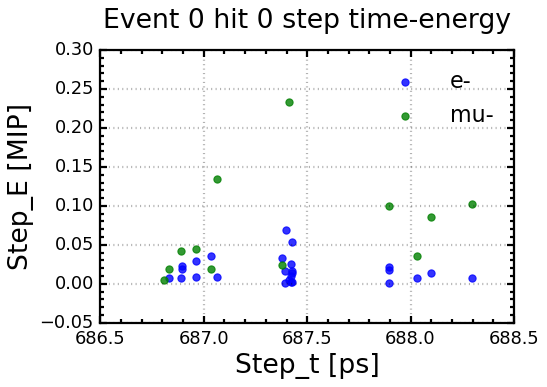

In [3]:
import pandas as pd
from IPython.display import display
from matplotlib.ticker import ScalarFormatter

STEP_TABLE_HIT_INDEX = 0
PARTICLE_NAME = {
    11: 'e-',
    -11: 'e+',
    13: 'mu-',
    -13: 'mu+',
    22: 'gamma',
}


def particle_name(pdg_id):
    return PARTICLE_NAME.get(int(pdg_id), f'PDG {int(pdg_id)}')


step_rows = []
for record in hit_records:
    if record['hit_index'] != STEP_TABLE_HIT_INDEX:
        continue
    for step_index, (step_e, step_t, track_id, pdg_id) in enumerate(zip(
        record['step_energy_mev'],
        record['step_time_ns'],
        record['step_track_id'],
        record['step_pdg_id'],
    )):
        step_rows.append({
            'hit_index': record['hit_index'],
            'cell_id': record['cell_id'],
            'step_index': step_index,
            'Step_E [MeV]': step_e,
            'Step_E [MIP]': step_e / CELL_SHAPING_CFG['mip_value_mev'],
            'Step_t [ns]': step_t,
            'trackID': track_id,
            'particle': particle_name(pdg_id),
        })

step_table = pd.DataFrame(step_rows)
if step_table.empty:
    print(f'No positive finite steps found for hit {STEP_TABLE_HIT_INDEX}.')
else:
    display(step_table)

    fig, ax = plt.subplots(figsize=(7, 5))
    particles = sorted(step_table['particle'].unique())
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    particle_colors = {particle: color_cycle[i % len(color_cycle)] for i, particle in enumerate(particles)}

    for particle, particle_steps in step_table.groupby('particle'):
        ax.scatter(
            particle_steps['Step_t [ns]'] * 1000.0,
            particle_steps['Step_E [MIP]'],
            s=42,
            alpha=0.8,
            color=particle_colors[particle],
            label=particle,
        )
    x_formatter = ScalarFormatter(useOffset=False)
    x_formatter.set_scientific(False)
    ax.xaxis.set_major_formatter(x_formatter)
    ax.ticklabel_format(axis='x', style='plain', useOffset=False)
    ax.set_xlabel('Step_t [ps]')
    ax.set_ylabel('Step_E [MIP]')
    ax.set_title(f'Event {EVENT_INDEX} hit {STEP_TABLE_HIT_INDEX} step time-energy')
    ax.grid(True, alpha=0.3)
    ax.legend(scatterpoints=1)
    fig.tight_layout()
    plt.show()


## CR-RC Response

The function below mirrors `CellShaping.hh`: each step contributes `E_step / MIP` times a normalized CR-RC response, and all step responses are summed.


In [4]:
def cr_rc_response(time_ns, step_energy_mev, step_time_ns, mip_value_mev, tau_ns, order):
    if order <= 0:
        raise ValueError('CR-RC order must be positive')
    if mip_value_mev <= 0.0:
        raise ValueError('mip_value_mev must be positive')

    tau = tau_ns / float(order)
    norm = 4.0 / factorial(order)
    time_ns = np.asarray(time_ns, dtype=np.float64)
    signal = np.zeros_like(time_ns, dtype=np.float64)

    for energy_mev, t0_ns in zip(step_energy_mev, step_time_ns):
        step_amplitude_mip = energy_mev / mip_value_mev
        t = (time_ns - t0_ns) / tau
        signal += np.where(t > 0.0, norm * step_amplitude_mip * np.power(t, order) * np.exp(-t), 0.0)
    return signal


def first_threshold_crossing(time_ns, signal, threshold, stop_time_ns):
    mask = (time_ns <= stop_time_ns) & (signal > threshold)
    indices = np.flatnonzero(mask)
    return float(time_ns[indices[0]]) if len(indices) else np.nan


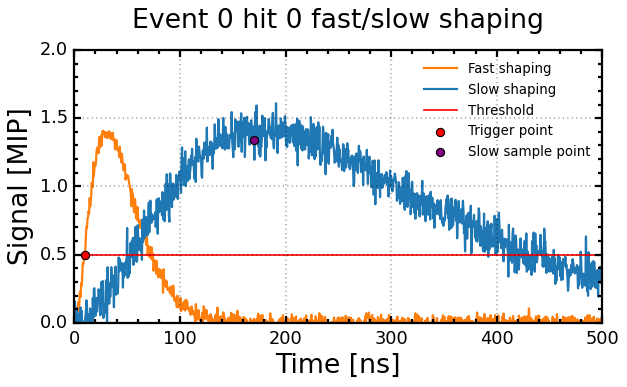

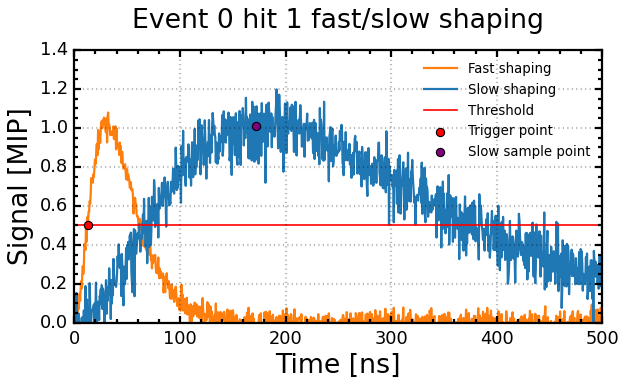

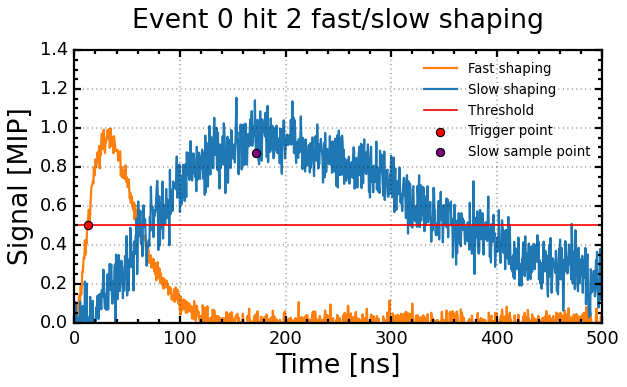

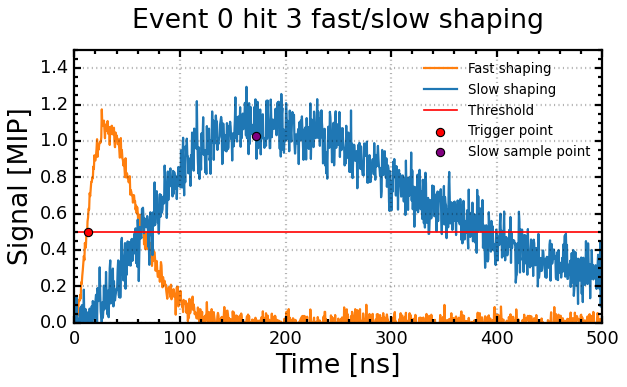

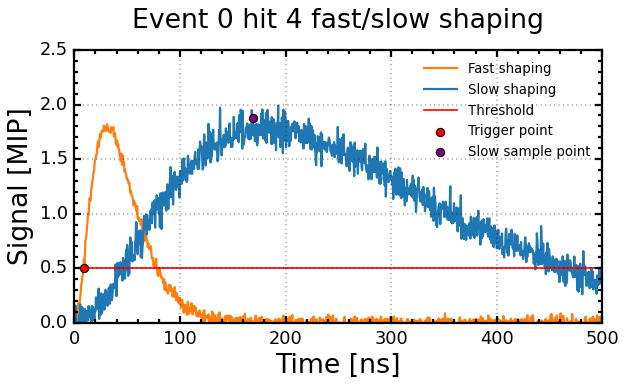

MIP value used [MeV/MIP]: 0.1472
hit 0 CellID=170497: E_hit=1.29732 MIP, steps=38, fast max=1.40797 MIP at 27.500 ns, slow max=1.61006 MIP at 191.000 ns, t_fast_thr=10.000 ns, slow(t_fast+delay)=1.34251 MIP
hit 1 CellID=170498: E_hit=0.935654 MIP, steps=17, fast max=1.07917 MIP at 32.000 ns, slow max=1.1978 MIP at 191.500 ns, t_fast_thr=12.500 ns, slow(t_fast+delay)=1.01131 MIP
hit 2 CellID=170499: E_hit=0.874396 MIP, steps=14, fast max=0.996696 MIP at 34.500 ns, slow max=1.15513 MIP at 153.500 ns, t_fast_thr=12.500 ns, slow(t_fast+delay)=0.870896 MIP
hit 3 CellID=170500: E_hit=1.00239 MIP, steps=18, fast max=1.17374 MIP at 26.000 ns, slow max=1.29761 MIP at 163.000 ns, t_fast_thr=12.500 ns, slow(t_fast+delay)=1.0269 MIP
hit 4 CellID=170501: E_hit=1.64637 MIP, steps=28, fast max=1.81943 MIP at 31.000 ns, slow max=1.9904 MIP at 193.000 ns, t_fast_thr=9.000 ns, slow(t_fast+delay)=1.87699 MIP


In [5]:
cfg = CELL_SHAPING_CFG

t_grid = np.linspace(0.0, cfg['slow_window_ns'], cfg['scan_steps'] + 1)
shaping_summary = []

for record in hit_records:
    step_energy_mev = record['step_energy_mev']
    step_time_ns = record['step_time_ns']

    fast_signal_clean = cr_rc_response(
        t_grid,
        step_energy_mev,
        step_time_ns,
        cfg['mip_value_mev'],
        cfg['tau_fast_ns'],
        cfg['order_fast'],
    )
    slow_signal_clean = cr_rc_response(
        t_grid,
        step_energy_mev,
        step_time_ns,
        cfg['mip_value_mev'],
        cfg['tau_slow_ns'],
        cfg['order_slow'],
    )

    fast_signal = fast_signal_clean + np.random.normal(0.0, cfg['fast_noise'], size=t_grid.shape)
    slow_signal = slow_signal_clean + np.random.normal(0.0, cfg['slow_noise'], size=t_grid.shape)

    fast_scan = t_grid <= cfg['fast_window_ns']
    slow_scan = t_grid <= cfg['slow_window_ns']
    fast_max_index = int(np.argmax(np.where(fast_scan, fast_signal, -np.inf)))
    slow_max_index = int(np.argmax(np.where(slow_scan, slow_signal, -np.inf)))
    fast_threshold_time = first_threshold_crossing(
        t_grid,
        fast_signal,
        cfg['mip_threshold'],
        t_grid[fast_max_index],
    )
    slow_sample_time = fast_threshold_time + cfg['delay_ns'] if np.isfinite(fast_threshold_time) else np.nan
    slow_sample_signal = (
        float(cr_rc_response(
            np.array([slow_sample_time]),
            step_energy_mev,
            step_time_ns,
            cfg['mip_value_mev'],
            cfg['tau_slow_ns'],
            cfg['order_slow'],
        )[0] + np.random.normal(0.0, cfg['slow_noise']))
        if np.isfinite(slow_sample_time)
        else np.nan
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(t_grid, fast_signal, color='tab:orange', linewidth=2, label='Fast shaping')
    ax.plot(t_grid, slow_signal, color='tab:blue', linewidth=2, label='Slow shaping')
    ax.axhline(cfg['mip_threshold'], color='red', linestyle='-', linewidth=1.5, label='Threshold')
    if np.isfinite(fast_threshold_time):
        ax.scatter(
            fast_threshold_time,
            cfg['mip_threshold'],
            color='red',
            edgecolor='black',
            s=55,
            zorder=5,
            label='Trigger point',
        )
    if np.isfinite(slow_sample_time) and slow_sample_time <= t_grid[-1]:
        ax.scatter(
            slow_sample_time,
            slow_sample_signal,
            color='purple',
            edgecolor='black',
            s=55,
            zorder=5,
            label='Slow sample point',
        )
    ax.set_xlabel('Time [ns]')
    ax.set_ylabel('Signal [MIP]')
    ax.set_xlim(0.0, cfg['slow_window_ns'])
    ax.set_ylim(bottom=0.0)
    ax.set_title(f"Event {EVENT_INDEX} hit {record['hit_index']} fast/slow shaping")
    lines, labels = ax.get_legend_handles_labels()
    ax.legend(lines, labels, fontsize=12, loc='upper right', scatterpoints=1)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    shaping_summary.append({
        'hit_index': record['hit_index'],
        'cell_id': record['cell_id'],
        'hit_energy_mip': float(record['hit_energy_mev'] / cfg['mip_value_mev']),
        'step_number': int(len(record['step_energy_mev'])),
        'fast_max_mip': float(fast_signal[fast_max_index]),
        'fast_tmax_ns': float(t_grid[fast_max_index]),
        'slow_max_mip': float(slow_signal[slow_max_index]),
        'slow_tmax_ns': float(t_grid[slow_max_index]),
        'fast_threshold_time_ns': float(fast_threshold_time) if np.isfinite(fast_threshold_time) else np.nan,
        'slow_sample_signal_mip': float(slow_sample_signal) if np.isfinite(slow_sample_signal) else np.nan,
    })

print(f'MIP value used [MeV/MIP]: {cfg["mip_value_mev"]:.6g}')
for item in shaping_summary:
    print(
        f"hit {item['hit_index']} CellID={item['cell_id']}: "
        f"E_hit={item['hit_energy_mip']:.6g} MIP, "
        f"steps={item['step_number']}, "
        f"fast max={item['fast_max_mip']:.6g} MIP at {item['fast_tmax_ns']:.3f} ns, "
        f"slow max={item['slow_max_mip']:.6g} MIP at {item['slow_tmax_ns']:.3f} ns, "
        f"t_fast_thr={item['fast_threshold_time_ns']:.3f} ns, "
        f"slow(t_fast+delay)={item['slow_sample_signal_mip']:.6g} MIP"
    )
